<a href="https://colab.research.google.com/github/nehasingh913833-gif/basic-ML/blob/main/DecisionTree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix
from sklearn.impute import SimpleImputer

loading the data

In [ ]:
from google.colab import files
uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

  df = pd.read_csv('weatherHistory.csv')

Saving weatherHistory.csv to weatherHistory.csv
User uploaded file "weatherHistory.csv" with length 16294377 bytes


data cleanning and preaparing

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  object 
dtypes: float64(8), object(4)
memory usage: 8.8+ MB


In [ ]:
df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [ ]:
df['Formatted Date'] = pd.to_datetime(df['Formatted Date'], utc=True)
df.set_index('Formatted Date', inplace=True)


numeric_cols = ['Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Pressure (millibars)']
daily_df = df[numeric_cols].resample('D').mean()
daily_df['Precip_Type'] = df['Precip Type'].resample('D').agg(lambda x: x.mode()[0] if not x.mode().empty else 'rain')


daily_df['Rain_Tomorrow'] = (daily_df['Precip_Type'].shift(-1) == 'rain').astype(int)
daily_df.dropna(inplace=True)


features = ['Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Pressure (millibars)']
X = daily_df[features]
y = daily_df['Rain_Tomorrow']

imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

Train/Test Split


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42)

decision tree

In [ ]:
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)

y_pred = dt_model.predict(X_test)



Evalusion matrix

In [ ]:
print("--- EVALUATION METRICS ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


--- EVALUATION METRICS ---
Accuracy:  0.9490
Precision: 0.9697
F1 Score:  0.9717

Confusion Matrix:
[[ 58  22]
 [ 19 705]]


Output


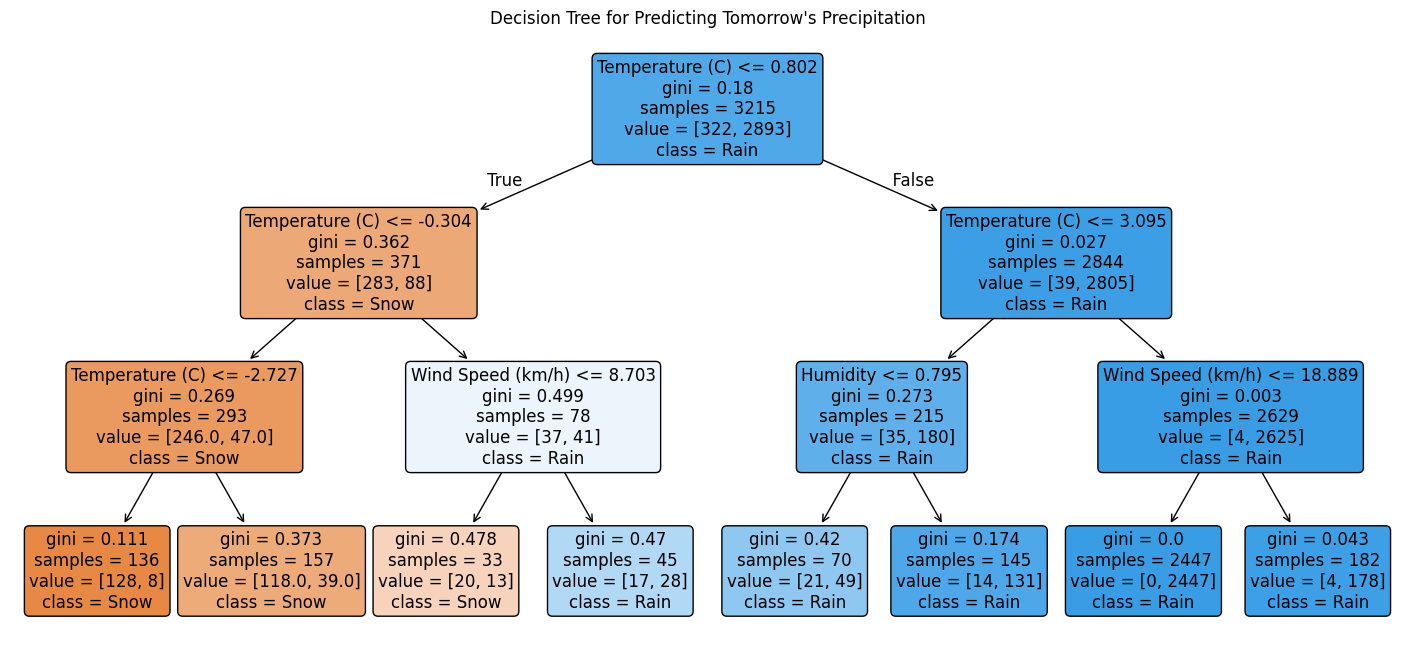

In [ ]:
plt.figure(figsize=(18, 8))
plot_tree(
    dt_model,
    feature_names=features,
    class_names=['Snow', 'Rain'],
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title("Decision Tree for Predicting Tomorrow's Precipitation")
plt.savefig('decision_tree_plot.png', bbox_inches='tight', dpi=150)